[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EQuS/jaxquantum/blob/main/docs/documentation/tutorials/sparse_backend.ipynb)

In [1]:
# !pip install git+https://github.com/EQuS/jaxquantum.git  # Uncomment when running in Colab.

# Sparse BCOO Backend

*This is an executable IPython Notebook tutorial.*

jaxquantum operators and states can be stored either as **dense** JAX arrays (the default) or as
**sparse** BCOO arrays via the JAX experimental sparse module.
Choosing `implementation="sparse_bcoo"` keeps all intermediate results sparse — arithmetic,
trace, norm, and diagonal extraction never materialise the full $N\times N$ dense matrix.
This is especially valuable for large truncated Hilbert spaces where the operators have
only $O(N)$ non-zero entries.

This tutorial covers three representative examples:

1. **Sparse Qarray basics** — creating and manipulating sparse operators.
2. **Decaying harmonic oscillator** — master equation simulation of photon loss.
3. **Fluxonium qubit** — using the `devices` submodule and converting to sparse for efficient operator algebra.

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import jaxquantum as jqt
import jax.numpy as jnp
import matplotlib.pyplot as plt

## 1. Sparse Qarray Basics

Pass `implementation="sparse_bcoo"` (or `implementation=jqt.QarrayImplType.SPARSE_BCOO`) to any operator
constructor to get a sparse Qarray backed by a JAX BCOO array.
Arithmetic between two sparse Qarrays stays sparse throughout.

In [4]:
N = 10

a    = jqt.destroy(N, implementation="sparse_bcoo")
adag = jqt.create(N,  implementation="sparse_bcoo")
n_op = jqt.num(N,     implementation="sparse_bcoo")
eye  = jqt.identity(N, implementation="sparse_bcoo")

print("a is sparse:", a.is_sparse_bcoo)
print("implementation:", a.impl_type)

a is sparse: True
implementation: QarrayImplType.SPARSE_BCOO


In [5]:
# Arithmetic stays sparse — sparse @ sparse = sparse
adag_a = adag @ a
print("adag @ a is sparse:", adag_a.is_sparse_bcoo)

# Verify a†a ≈ n̂ via the trace (both equal 0+1+…+(N-1) = 45).
# BCOO matmul can produce a different index structure than fromdense, so we
# compare the traces rather than using == (which does structural index comparison).
print("tr(a†a)  =", float(jnp.real(jqt.tr(adag_a))))   # should be N*(N-1)/2 = 45
print("tr(n̂)    =", float(jnp.real(jqt.tr(n_op))))

# Scalar shift: adds a scaled identity WITHOUT creating a dense N×N matrix
H_osc = n_op + 0.5         # zero-point energy shift  ω*(n̂ + ½)
print("n + 0.5 is sparse:", H_osc.is_sparse_bcoo)

adag @ a is sparse: True
tr(a†a)  = 45.0
tr(n̂)    = 45.0
n + 0.5 is sparse: True


In [6]:
# Sparse-native operations — no densification occurs

# Trace: sum of diagonal entries via scatter (O(nnz), not O(N²))
print("tr(n_op)  =", float(jnp.real(jqt.tr(n_op))))   # 0+1+…+9 = 45

# Norm of a sparse ket (L2 norm) and a sparse density matrix (trace norm)
ket3  = jqt.basis(N, 3, implementation="sparse_bcoo")       # Fock state |3⟩
rho3  = jqt.ket2dm(ket3)                               # |3⟩⟨3|  — stays sparse
print("norm(|3⟩)  =", float(jqt.norm(ket3)))           # L2 norm = 1 for any basis state
print("norm(ρ₃)   =", float(jnp.real(jqt.norm(rho3)))) # trace norm = tr(ρ) = 1 (pure state)

# keep_only_diag_elements: zeros off-diagonal stored values in-place (no todense)
diag_only = jqt.keep_only_diag_elements(H_osc)
print("diagonal H_osc is sparse:", diag_only.is_sparse_bcoo)

# Round-trip conversion
a_dense  = a.to_dense()
a_sparse = a_dense.to_sparse_bcoo()
print("dense → sparse round-trip correct:", a_sparse == a)

tr(n_op)  = 45.0
norm(|3⟩)  = 1.0
norm(ρ₃)   = 1.0
diagonal H_osc is sparse: True
dense → sparse round-trip correct: True


## 2. Decaying Harmonic Oscillator

We simulate a single bosonic mode starting in Fock state $|n_0\rangle$ and coupled to
a zero-temperature bath with photon-loss rate $\kappa$.  The Lindblad master equation is

$$\dot{\rho} = -i[\omega\,\hat{n},\,\rho] + \kappa\!\left(\hat{a}\rho\hat{a}^\dagger - \tfrac{1}{2}\{\hat{a}^\dagger\hat{a},\rho\}\right)$$

and the analytic expectation value decays as $\langle \hat{n}\rangle(t) = n_0\,e^{-\kappa t}$.

> **Note:** The Hamiltonian is built and passed to `jqt.mesolve` as a sparse Qarray.
> JAX handles `BCOO @ dense` natively in the ODE right-hand side, so no conversion
> is needed.  The ODE *state* (density matrix $\rho$) remains dense throughout the
> integration — only $H$, the collapse operators (`c_ops`) and the expectation-value operator take advantage of sparse
> storage.

In [7]:
N     = 20
omega = 1.0   # oscillator frequency (natural units)
kappa = 0.2   # photon-loss rate
n0    = 4     # initial Fock state |n0⟩

# Build operators sparsely
H     = omega * jqt.num(N, implementation="sparse_bcoo")
a_dm  = jqt.destroy(N)                              # dense collapse operator
c_ops = jqt.Qarray.from_list([jnp.sqrt(kappa) * a_dm]).to_sparse_bcoo()

print("H is sparse:", H.is_sparse_bcoo)

# Initial state: |n0⟩ as a density matrix
rho0 = jqt.ket2dm(jqt.basis(N, n0))

tlist  = jnp.linspace(0.0, 30.0, 300)
result = jqt.mesolve(
    H, rho0, tlist,
    c_ops=c_ops,
    solver_options=jqt.SolverOptions.create(progress_meter=False),
)
print("result shape (T, N, N):", result.data.shape)

H is sparse: True
result shape (T, N, N): (300, 20, 20)


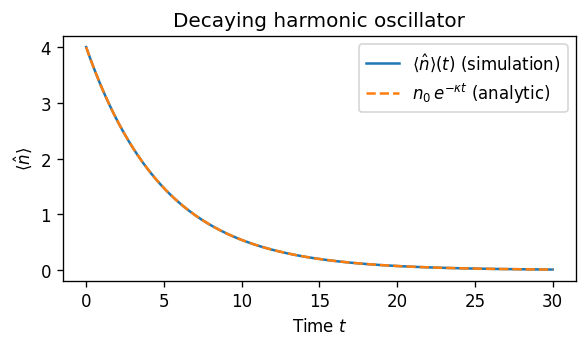

In [8]:
# Expectation value ⟨n̂⟩(t) = tr(n̂ ρ(t)) — broadcasts over the time batch dimension
n_dense  = jqt.num(N, implementation="sparse_bcoo")
n_expect = jnp.real(jqt.tr(n_dense @ result))

fig, ax = plt.subplots(figsize=(5, 3), dpi=120)
ax.plot(tlist, n_expect,                           label=r"$\langle\hat{n}\rangle(t)$ (simulation)")
ax.plot(tlist, n0 * jnp.exp(-kappa * tlist), "--", label=r"$n_0\,e^{-\kappa t}$ (analytic)")
ax.set_xlabel("Time $t$")
ax.set_ylabel(r"$\langle\hat{n}\rangle$")
ax.set_title("Decaying harmonic oscillator")
ax.legend()
fig.tight_layout()